# Jupyter-notebook for testing operations (mainly for comparison)

In [2]:
import numpy as np
from scipy import linalg

In [3]:
# Typical representation
A0 = np.array([[-1, 0, 0, 0],
               [0, 1, 0, 0],
               [0, 0, -10, -4],
               [0, 0, 4, -10]])
A1 = np.array([[3, 3, 3, 3],
               [0, -1.5, 0, 0],
               [0, 0, 3, -5],
               [0, 5, 5, 5]])
A=np.stack([A0, A1], axis=2)
hA=np.array([0, 1.])
E = np.eye(4)

In [4]:
# perform tests
complex_vector = np.random.rand(10) + np.random.rand(10)*1j

for z in complex_vector:
    M1 = z*E + np.sum(A * np.exp(-hA*z), axis=2)

    M2 = z*E
    for i in range(len(hA)):
        M2 = M2 + A[:,:,i] * np.exp(-z*hA[i])
    
    max_error = np.max(np.abs(M1-M2))
    print(f"{z=}, {max_error=}")



z=(0.6587513260833927+0.104476746141409j), max_error=8.881784197001252e-16
z=(0.2624167145847992+0.9021886946520704j), max_error=8.881784197001252e-16
z=(0.7690619140285806+0.9284566841867815j), max_error=8.881784197001252e-16
z=(0.08535132847755078+0.06319746177232388j), max_error=8.881784197001252e-16
z=(0.9060340953817196+0.8444918447732518j), max_error=8.881784197001252e-16
z=(0.2761380755564088+0.9611323148131191j), max_error=1.7763568394002505e-15
z=(0.5562509409184982+0.9980718690431981j), max_error=1.7763568394002505e-15
z=(0.1601783624128328+0.6498095431849186j), max_error=0.0
z=(0.9103020758677173+0.6458917080956402j), max_error=2.220446049250313e-16
z=(0.5700370746830175+0.6605129718828153j), max_error=8.881784197001252e-16


In [5]:
# Controller gradient computation
m,n,k = 3,4,6
tau_vector = np.array([i*0.1 for i in range(k)])
Kmask = np.random.rand(m,n,k) > 0.5
BKC = np.random.rand(m,n)


In [6]:
Kmask * tau_vector

array([[[0. , 0. , 0.2, 0.3, 0.4, 0.5],
        [0. , 0.1, 0. , 0. , 0.4, 0.5],
        [0. , 0.1, 0. , 0.3, 0. , 0. ],
        [0. , 0.1, 0.2, 0. , 0. , 0.5]],

       [[0. , 0. , 0. , 0.3, 0.4, 0. ],
        [0. , 0.1, 0.2, 0. , 0.4, 0. ],
        [0. , 0. , 0.2, 0.3, 0. , 0. ],
        [0. , 0.1, 0. , 0.3, 0. , 0. ]],

       [[0. , 0. , 0.2, 0. , 0. , 0.5],
        [0. , 0.1, 0.2, 0. , 0. , 0. ],
        [0. , 0.1, 0. , 0. , 0.4, 0.5],
        [0. , 0.1, 0. , 0. , 0.4, 0. ]]])

In [7]:
result = (Kmask * tau_vector) * BKC[:,:,np.newaxis]
for i in range(result.shape[2]):
    error = result[:,:,i] - np.multiply(Kmask[:,:,i]*tau_vector[i], BKC)
    print(np.allclose(error, 0))

True
True
True
True
True
True


In [8]:
result[:,:,0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [9]:
# Indexation of 3D arrays
n = 10
AA = []
for i in range(5):
    AA.append(
        (i+1) * np.eye(n)
    )

A=np.stack(AA, axis=2)

In [10]:
row_index = [0,2]
col_index = [0,1,2,3]
#row_index = np.array([0,2])
#col_index = np.array([0,1,2,3])
result = A[np.ix_(row_index, col_index, range(A.shape[2]))]



print(f"{result.shape}")
for k in range(result.shape[2]):
    print(result[:,:,k])

(2, 4, 5)
[[1. 0. 0. 0.]
 [0. 0. 1. 0.]]
[[2. 0. 0. 0.]
 [0. 0. 2. 0.]]
[[3. 0. 0. 0.]
 [0. 0. 3. 0.]]
[[4. 0. 0. 0.]
 [0. 0. 4. 0.]]
[[5. 0. 0. 0.]
 [0. 0. 5. 0.]]


In [35]:
n, m, k = 3, 5, 10
nn = 8

tau_vector = np.array([i*0.1 for i in range(k)])

np.random.seed(10)
K = np.random.rand(m,n,k)
B = np.random.rand(nn, m)
C = np.random.rand(n, nn)

In [44]:
res1 = B @ K[:,:,0] @ C

In [45]:
res2 = np.tensordot(B, K, axes=((2), (1)))


def func_loop(K, B, C):
    pass    

def func_einsum(K,B,C):
    return np.einsum(
        'ijk,jn->ink',# i==n also
        np.einsum('ni,ijk->njk', B, K),
        C,
    )



IndexError: tuple index out of range

In [46]:
res2 = np.einsum(
    'ijk,jn->ink',# i==n also
    np.einsum('ni,ijk->njk', B, K),
    C,
)

In [49]:
timeit lambda x: 10

31.8 ns ± 0.181 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [30]:
np.ix_(row_index, col_index, range(A.shape[2]))

(array([[[0]],
 
        [[1]],
 
        [[4]]]),
 array([[[0],
         [1],
         [2],
         [3]]]),
 array([[[0, 1, 2, 3, 4]]]))

In [ ]:
np.indices()

In [4]:
A = np.random.rand(4,4,10)

In [9]:
AA = A[:,:, [1,0,3]]

In [11]:
np.isclose(AA[:,:,0], A[:,:,1])

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [14]:
np.concatenate([np.array([1,1,1]),np.array([]), np.array([2,2])], axis=0)

array([1., 1., 1., 2., 2.])

In [ ]:
# Comparison
A = np.stack([A0, A1, A1*10], axis=2) # (n_states, n_states, n_delays)
hA = hA=np.array([0, 1., 2, 3])

In [4]:
np.concatenate([A0[:,:,np.newaxis], A], axis=2)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 4 and the array at index 1 has size 2

In [5]:
DD = np.random.rand(3,3,4)
hDD = np.array([0.3, 0.46, 0.48, 1.5])
u = np.random.rand(3,) + 1j*np.random.rand(3,)
v = np.random.rand(3,) + 1j*np.random.rand(3,)

In [6]:
# one shot


In [7]:
DD.shape

(3, 3, 4)

In [8]:
np.conj(u[np.newaxis, ]) @ DD[:,:,0]

array([[0.9297204 -0.26193806j, 1.86890252-0.52321453j,
        1.74444528-0.5550986j ]])

In [9]:
np.ravel()

TypeError: ravel() missing 1 required positional argument: 'a'

In [64]:
pom = np.conj(u[np.newaxis, np.newaxis, ]) @ np.transpose(DD, (1,0,2))
pom

array([[[0.35420586-0.10532599j, 0.99196665-0.5031648j ,
         1.18214463-0.75940259j, 1.31047856-0.63000362j]],

       [[0.88901118-0.61335586j, 1.61633642-0.72388863j,
         0.88541662-0.57948834j, 1.06701478-0.38574745j]],

       [[0.73177854-0.37038361j, 0.73973774-0.48182061j,
         1.50150753-0.75744051j, 0.87277868-0.51356456j]]])

In [65]:
pom.shape

(3, 1, 4)

In [66]:
r = v[np.newaxis, :] @ np.transpose(pom, (1,0,2)) 

In [67]:
np.ravel(r).shape

(4,)

In [68]:
np.ravel(r)

array([1.93551363+0.56210115j, 3.41212929+1.17027306j,
       3.3489107 +1.3697247j , 3.01398257+1.45968292j])

In [69]:
np.conj(u[np.newaxis, ]) @ np.transpose(v[np.newaxis, :] @ DD, (1,0,2))

array([[[1.93551363+0.56210115j, 3.41212929+1.17027306j,
         3.3489107 +1.3697247j , 3.01398257+1.45968292j]]])

## Constructing nullspaces

In [12]:
E = np.eye(4)

In [13]:
E

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [15]:
uE = linalg.null_space(E.T)
vE = linalg.null_space(E)

In [16]:
uE

array([], shape=(4, 0), dtype=float64)

In [17]:
vE

array([], shape=(4, 0), dtype=float64)

In [18]:
uE.size

0

In [19]:
np.array([[[]]])

array([], shape=(1, 1, 0), dtype=float64)

In [21]:
np.empty(shape=(4,4,0))

array([], shape=(4, 4, 0), dtype=float64)

In [1]:
np.empty_like()

NameError: name 'np' is not defined

In [11]:
omega = 24
xi = 0.1
z = -omega*xi + 1j*omega*(1-xi**2)**0.5


In [12]:
T = omega*(1-xi**2)**0.5
N = 10 # N+1 if from 0
tau_vector = np.linspace(0, 0.4, N)
a_vector = np.ones(N)
gamma = 0.3



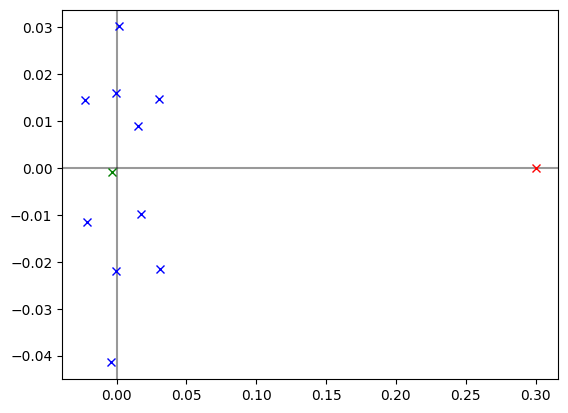

In [18]:
import matplotlib.pyplot as plt

plt.axvline(0, color="k", alpha=0.4)
plt.axhline(0, color="k", alpha=0.4)
plt.plot(np.real(gamma), np.imag(gamma), "rx")
plt.plot(np.real(1/z * np.exp(z)), np.imag(1/z * np.exp(z)), "gx")

plt.plot(np.real(1/z*np.exp(z*tau_vector)*a_vector), np.imag(1/z*np.exp(z*tau_vector)*a_vector), "bx")


In [17]:
1/z * np.exp(z)

(-0.0036907895305840275-0.0008159828027408845j)

In [19]:
np.exp(tau_vector*z) - np.exp(tau_vector)*np.exp(z)

array([ 0.97165668+0.08617658j,  0.40874379+0.87476747j,
       -0.45451921+0.78215115j, -0.75788337+0.06771236j,
       -0.32776471-0.47981871j,  0.29304025-0.37846805j,
        0.48839542+0.15713889j,  0.15661854+0.54945742j,
       -0.29367519+0.46552712j, -0.42208754+0.08002504j])

In [ ]:
N = 10
T = 0.4


def create_shaper(N: int, T: float, s0: complex):
    """
                    1
    S(s) = gamma + --- (a0*exp(-s*tau0) + ... + aN*exp(-s*tauN))
                    s
    """
    assert N > 1
    assert T > 0

    tau_vector = np.linspace(0, T, N+1)

    






